# Hardware

Everything we have built so far lives on paper and in simulation. Algorithms, gates,
entanglement, error correction: all elegant, all theoretical. The question that has
been hanging over every chapter finally demands an answer.

The answer is yes, with enormous difficulty. Simple quantum devices consisting
of a few qubits have been built and tested. Scaling them up remains one of the
hardest engineering challenges in physics. This chapter surveys the obstacles,
the leading hardware proposals, and the road ahead.

The presentation here is deliberately elementary. Quantum hardware lives at
the intersection of quantum physics and quantum engineering, well beyond what
we have asked of the reader so far. The goal is orientation, not mastery.

In [1]:
import numpy as np
from numpy import sqrt, cos, sin, exp, pi, log2, kron
import matplotlib.pyplot as plt

## 11.1 Quantum Hardware: Goals and Challenges

Recall the generic architecture from Chapter 6: we need addressable qubits,
the ability to initialize them, a way to apply unitary transformations
(gates), and a way to measure the result.

Initialization resembles its classical counterpart. We set the machine to a
**well-defined state** and then modify it through controlled computational
steps. For a classical computer this is straightforward: a classical machine
can be treated as an *isolated system*, largely decoupled from its environment.

A quantum computer is a different story.

### Pure States and Mixed States

Entanglement, one of quantum mechanics' core features, means that if a system
$S$ is composed of two subsystems $S_1$ and $S_2$, their states may become entangled.
We cannot ignore what happens to $S_2$ if we care about $S_1$, regardless of how
far apart they are physically.

For quantum computing, this matters because the machine and its environment
can become entangled, preventing the quantum register's evolution from depending
solely on the gates we apply.

Suppose our device stores 1,000 electrons as spin qubits. Initialization means
setting all spins to a known configuration (say, all spin up). The key requirement:
we must control the *global* state of the register. In physics, a well-defined
state is called a **pure state**.

When we take our register out of isolation, the electrons couple with billions
of environmental electrons, shifting into some superposition of spin up and
spin down. We have no idea about the environment's precise initial state or
the details of the interaction. After a while, the global state of the quantum
register is no longer pure; it has become a probabilistic mix of pure states,
known as a **mixed state**.

Pure states and mixed states have fundamentally different status in quantum
mechanics. There is always a specific measurement that invariably returns
true on a pure state. No such guarantee exists for mixed states.

### Exercise 11.1.1

Consider the pure state $|\psi\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$
and the mixed state obtained by tossing a coin and picking $|0\rangle$ (heads)
or $|1\rangle$ (tails). Devise an experiment that discriminates between these two states.

**Hint:** measure in the basis $\left\{\frac{|0\rangle+|1\rangle}{\sqrt{2}},\;\frac{|0\rangle-|1\rangle}{\sqrt{2}}\right\}$.

**Solution.** In the standard basis, both give 50/50 outcomes for $|0\rangle$ vs $|1\rangle$.
They look identical. But switch to the Hadamard basis
$\{|+\rangle, |-\rangle\}$ where $|+\rangle = |\psi\rangle$ itself.
Measuring $|\psi\rangle$ in this basis *always* yields $|+\rangle$ (probability 1).
The mixed state, however, gives $|+\rangle$ half the time and $|-\rangle$ half the time.
The change of basis discriminates them perfectly.

In [2]:
# Exercise 11.1.1: Discriminating pure vs mixed states
#
# Pure state: |psi> = (|0> + |1>) / sqrt(2)
# Mixed state: 50% |0>, 50% |1>  (classical coin flip)
#
# Hadamard basis vectors
plus  = np.array([1, 1]) / sqrt(2)   # |+>
minus = np.array([1, -1]) / sqrt(2)  # |->

# The pure state IS |+>, so measuring in {|+>,|->} gives:
psi = plus.copy()
p_plus_pure  = abs(plus @ psi)**2
p_minus_pure = abs(minus @ psi)**2
print("Pure state |psi> measured in Hadamard basis:")
print(f"  P(|+>) = {p_plus_pure:.4f}")
print(f"  P(|->) = {p_minus_pure:.4f}")
print()

# The mixed state: coin-flip between |0> and |1>
ket0 = np.array([1, 0], dtype=float)
ket1 = np.array([0, 1], dtype=float)

# Probability of |+> when state is |0>
p_plus_from_0 = abs(plus @ ket0)**2
# Probability of |+> when state is |1>
p_plus_from_1 = abs(plus @ ket1)**2

# Average over the coin flip (50/50)
p_plus_mixed  = 0.5 * p_plus_from_0 + 0.5 * p_plus_from_1
p_minus_mixed = 1 - p_plus_mixed

print("Mixed state (coin flip) measured in Hadamard basis:")
print(f"  P(|+>) = {p_plus_mixed:.4f}")
print(f"  P(|->) = {p_minus_mixed:.4f}")
print()
print("The pure state always gives |+>.")
print("The mixed state gives each outcome half the time.")
print("The Hadamard basis measurement distinguishes them.")

Pure state |psi> measured in Hadamard basis:
  P(|+>) = 1.0000
  P(|->) = 0.0000

Mixed state (coin flip) measured in Hadamard basis:
  P(|+>) = 0.5000
  P(|->) = 0.5000

The pure state always gives |+>.
The mixed state gives each outcome half the time.
The Hadamard basis measurement distinguishes them.


### Relative Phase and Decoherence

The difference between pure and mixed states comes down to **relative phase**.
Consider the family of spin states parameterized by angle $\theta$:

$$|\psi_\theta\rangle = \frac{|0\rangle + e^{i\theta}|1\rangle}{\sqrt{2}}$$

Each value of $\theta$ gives a distinct pure state. Measuring in the standard basis
cannot distinguish them (the probabilities are always 50/50). But measure
the average spin along the $x$ axis, $\langle\psi_\theta|S_x|\psi_\theta\rangle$,
and the phase becomes visible.

When a pure state decoheres into a mixed state (a coin flip between $|0\rangle$
and $|1\rangle$), the relative phase and all the information it carries is lost.
This is precisely what separates pure states from mixed ones. One way states
change from pure to mixed is through uncontrollable interaction with the
environment.

### Exercise 11.1.2

Calculate $\langle\psi_\theta|S_x|\psi_\theta\rangle$. For which value of
$\theta$ is the average maximum?

**Solution.** Writing $|\psi_\theta\rangle = \frac{1}{\sqrt{2}}[1, e^{i\theta}]^T$
in the standard basis, and $S_x = \begin{bmatrix}0&1\\1&0\end{bmatrix}$
(ignoring the factor $\hbar/2$):

$$\langle\psi_\theta|S_x|\psi_\theta\rangle
= \frac{1}{2}[1, e^{-i\theta}]\begin{bmatrix}0&1\\1&0\end{bmatrix}[1, e^{i\theta}]^T
= \frac{1}{2}(e^{-i\theta} + e^{i\theta}) = \cos\theta$$

The average depends on $\theta$ and reaches its maximum at $\theta = 0$.

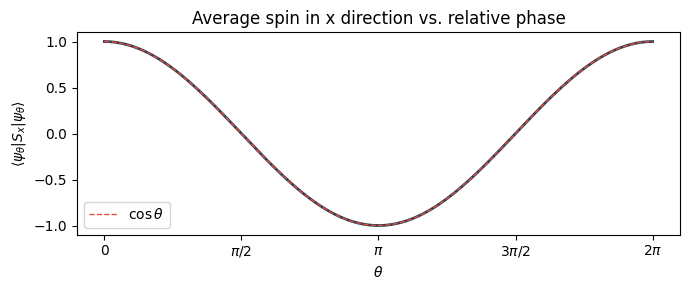

Maximum average = 1.0000 at theta = 0
The phase theta is directly observable through spin measurements.


In [3]:
# Exercise 11.1.2: <psi_theta | S_x | psi_theta> = cos(theta)

S_x = np.array([[0, 1],
                 [1, 0]], dtype=complex)

thetas = np.linspace(0, 2*pi, 200)
averages = []

for th in thetas:
    psi = np.array([1, exp(1j * th)]) / sqrt(2)
    avg = np.real(psi.conj() @ S_x @ psi)
    averages.append(avg)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thetas, averages, color='#2c3e50', linewidth=2)
ax.plot(thetas, np.cos(thetas), '--', color='#e74c3c', linewidth=1,
        label=r'$\cos\theta$')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\langle\psi_\theta|S_x|\psi_\theta\rangle$')
ax.set_title('Average spin in x direction vs. relative phase')
ax.legend()
ax.set_xticks([0, pi/2, pi, 3*pi/2, 2*pi])
ax.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.tight_layout()
plt.show()

print(f"Maximum average = {max(averages):.4f} at theta = 0")
print("The phase theta is directly observable through spin measurements.")

### Decoherence

> **Definition 11.1.1.** The loss of purity of the state of a quantum system
> as the result of entanglement with the environment is known as **decoherence**.

In all our previous work we implicitly assumed that we knew exactly how
the environment affects the quantum system. Under that assumption, the
system always evolves from pure states to other pure states (the only
unpredictable element is measurement).

In reality, a single electron spin sits in a vast environment. We can model
the whole thing as one huge quantum system, but we have no information
about the environment's initial state or the details of the interaction.
We restrict ourselves to a single external electron and suppose our qubit
has become entangled with it, forming the global state:

$$|\psi_{\text{global}}\rangle = \frac{|00\rangle + e^{i\theta}|11\rangle}{\sqrt{2}}$$

If we measure only *our* electron's spin along the $x$ axis (i.e., the observable
$S_x \otimes I$), the phase $\theta$ disappears entirely from the result. The phase
is hidden behind the curtain of entanglement. To recover it, we must measure
*both* electrons jointly.

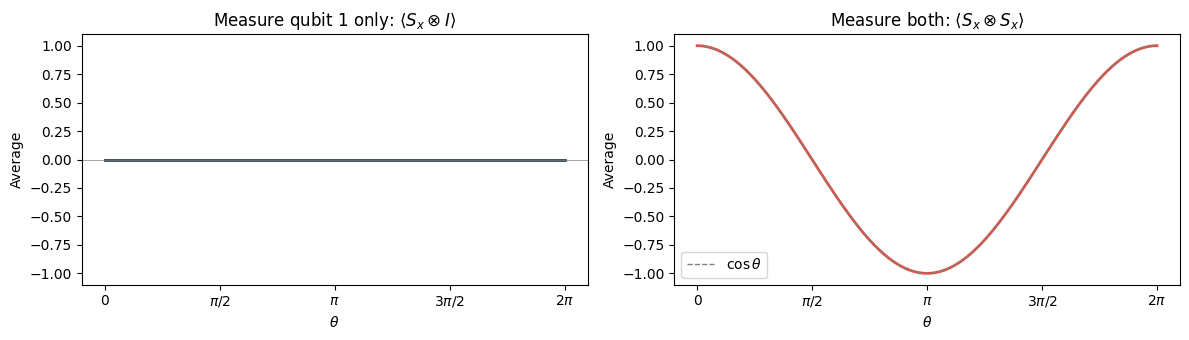

Left: measuring only qubit 1 gives 0 for all theta.
  The phase is completely hidden by entanglement.
Right: measuring both qubits recovers cos(theta).
  The phase was not destroyed, just delocalized.


In [4]:
# Decoherence: tracing out the environment from an entangled state
#
# Global state: (|00> + exp(i*theta)|11>) / sqrt(2)
# Measuring S_x on qubit 1 only: S_x tensor I
#   => phase theta vanishes
# Measuring S_x tensor S_x on both qubits:
#   => phase theta reappears

S_x = np.array([[0, 1], [1, 0]], dtype=complex)
I2  = np.eye(2, dtype=complex)

# Observable for qubit 1 only
Sx_I = np.kron(S_x, I2)
# Observable for joint measurement
Sx_Sx = np.kron(S_x, S_x)

thetas = np.linspace(0, 2*pi, 200)
single_avgs = []
joint_avgs  = []

for th in thetas:
    # Global state in standard basis: [1, 0, 0, exp(i*theta)] / sqrt(2)
    psi_global = np.array([1, 0, 0, exp(1j*th)], dtype=complex) / sqrt(2)
    
    single_avg = np.real(psi_global.conj() @ Sx_I @ psi_global)
    joint_avg  = np.real(psi_global.conj() @ Sx_Sx @ psi_global)
    
    single_avgs.append(single_avg)
    joint_avgs.append(joint_avg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

ax1.plot(thetas, single_avgs, color='#2c3e50', linewidth=2)
ax1.set_title(r'Measure qubit 1 only: $\langle S_x \otimes I \rangle$')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Average')
ax1.set_ylim(-1.1, 1.1)
ax1.set_xticks([0, pi/2, pi, 3*pi/2, 2*pi])
ax1.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax1.axhline(0, color='gray', linewidth=0.5)

ax2.plot(thetas, joint_avgs, color='#e74c3c', linewidth=2)
ax2.plot(thetas, np.cos(thetas), '--', color='gray', linewidth=1,
         label=r'$\cos\theta$')
ax2.set_title(r'Measure both: $\langle S_x \otimes S_x \rangle$')
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel('Average')
ax2.set_ylim(-1.1, 1.1)
ax2.set_xticks([0, pi/2, pi, 3*pi/2, 2*pi])
ax2.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.legend()

plt.tight_layout()
plt.show()

print("Left: measuring only qubit 1 gives 0 for all theta.")
print("  The phase is completely hidden by entanglement.")
print("Right: measuring both qubits recovers cos(theta).")
print("  The phase was not destroyed, just delocalized.")

### Exercise 11.1.3

Compute $\langle\psi_{\text{global}}|S_x \otimes S_x|\psi_{\text{global}}\rangle$.

**Solution.** First, $S_x \otimes S_x$ is the 4x4 matrix with 1s on the anti-diagonal:

$$S_x \otimes S_x = \begin{bmatrix}0&0&0&1\\0&0&1&0\\0&1&0&0\\1&0&0&0\end{bmatrix}$$

With $|\psi_{\text{global}}\rangle = \frac{1}{\sqrt{2}}[1, 0, 0, e^{i\theta}]^T$, the expectation is:

$$\frac{1}{2}(e^{-i\theta} + e^{i\theta}) = \cos\theta$$

The phase $\theta$ reappears in the joint measurement. Entanglement did not
destroy the phase information; it delocalized it across the two-particle system.

In [5]:
# Exercise 11.1.3: Verify <psi_global | Sx x Sx | psi_global> = cos(theta)

Sx_Sx = np.kron(S_x, S_x)
print("S_x tensor S_x:")
print(np.real(Sx_Sx).astype(int))
print()

# Check a few values
for th_val in [0, pi/4, pi/2, pi, 3*pi/2]:
    psi_g = np.array([1, 0, 0, exp(1j*th_val)]) / sqrt(2)
    result = np.real(psi_g.conj() @ Sx_Sx @ psi_g)
    print(f"  theta = {th_val:.4f}:  <Sx x Sx> = {result:+.4f},  cos(theta) = {cos(th_val):+.4f}")

S_x tensor S_x:
[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]]

  theta = 0.0000:  <Sx x Sx> = +1.0000,  cos(theta) = +1.0000
  theta = 0.7854:  <Sx x Sx> = +0.7071,  cos(theta) = +0.7071
  theta = 1.5708:  <Sx x Sx> = +0.0000,  cos(theta) = +0.0000
  theta = 3.1416:  <Sx x Sx> = -1.0000,  cos(theta) = -1.0000
  theta = 4.7124:  <Sx x Sx> = -0.0000,  cos(theta) = -0.0000


In [6]:
# Pure vs mixed state: density matrix view
# A pure state rho has Tr(rho^2) = 1; a mixed state has Tr(rho^2) < 1.

# Pure state |+> = (|0> + |1>) / sqrt(2)
psi_pure = np.array([[1], [1]]) / sqrt(2)
rho_pure = psi_pure @ psi_pure.conj().T

# Mixed state: 50% |0><0| + 50% |1><1|
rho_mixed = 0.5 * np.array([[1, 0], [0, 0]]) + 0.5 * np.array([[0, 0], [0, 1]])

print("Pure state density matrix:")
print(rho_pure)
print(f"  Tr(rho^2) = {np.real(np.trace(rho_pure @ rho_pure)):.4f}")
print()
print("Mixed state density matrix:")
print(rho_mixed)
print(f"  Tr(rho^2) = {np.real(np.trace(rho_mixed @ rho_mixed)):.4f}")
print()
print("Off-diagonal elements (coherences) encode phase.")
print(f"  Pure:  rho[0,1] = {rho_pure[0,1]:.4f}")
print(f"  Mixed: rho[0,1] = {rho_mixed[0,1]:.4f}")
print("Decoherence zeroes out the off-diagonal terms.")

Pure state density matrix:
[[0.5 0.5]
 [0.5 0.5]]
  Tr(rho^2) = 1.0000

Mixed state density matrix:
[[0.5 0. ]
 [0.  0.5]]
  Tr(rho^2) = 0.5000

Off-diagonal elements (coherences) encode phase.
  Pure:  rho[0,1] = 0.5000
  Mixed: rho[0,1] = 0.0000
Decoherence zeroes out the off-diagonal terms.


### The Decoherence Challenge

Now imagine our electron interacting not with one peer but with billions
of particles from the environment, in an unknown manner. If we could track
them all down and measure their states, the phase could in principle be
recovered. In practice, we cannot: the phase is irretrievably lost, turning
our pure state into a mixed one.

Note that decoherence does not cause any real collapse of the state vector.
The information is still out there, marooned in the vast quantum ocean.

Decoherence presents a two-pronged challenge:

- Quantum systems that couple easily with their environment (like electrons)
  are hard to keep isolated. Yet they need to interact with peers in the
  register, making the state difficult to manage.
- We *do* need to interact with the device to initialize it, apply gates, and
  read it out. A system that stays completely aloof (like photons) is hard to
  access.

Decoherence times vary by implementation. For trapped ions, coherence can
last 1 to 10 seconds. That sounds brief, but it is an eternity compared to
gate operation times in some architectures.

Two main strategies for coping:

1. **Fast gate execution.** Make decoherence slow relative to gate speed.
   Beat nature in the speed race, getting meaningful results from short runs.
2. **Fault tolerance.** Use quantum error-correcting codes (Chapter 10) to
   build in redundancy. Repeat calculations so random errors cancel.

### DiVincenzo's Five Criteria

David P. DiVincenzo of IBM formulated a wish list that every candidate
quantum computer must satisfy:

1. **Scalable qubits.** The machine must have a sufficiently large number
   of individually addressable qubits.
2. **Initialization.** It must be possible to initialize all qubits to the
   zero state, $|00\cdots0\rangle$.
3. **Low error rate.** The error rate in computations must be reasonably low;
   decoherence time must substantially exceed gate operation time.
4. **Universal gate set.** We must be able to perform elementary logical
   operations between pairs of qubits (a universal two-qubit gate).
5. **Reliable readout.** We must be able to reliably read out measurement
   results.

Every hardware proposal we examine below can be evaluated against
these five points.

## 11.2 Ion Traps

Any physical quantum system with a two-dimensional state space can, in
principle, store a qubit. The standard strategy: find systems that are
naturally two-dimensional, then assemble a collection of them into a register.
Particles with spin (electrons, single atoms) are canonical examples.
Spin is not the only option; excited states of atoms work too.

The steps for any implementation:

1. Initialize all particles to a well-defined state
2. Perform controlled single-qubit rotations (single-qubit gates)
3. Mix states of two particles (two-qubit gates)
4. Measure individual particles
5. Keep the system insulated from the environment during gate operations

The **ion trap** is the oldest and (at the time of writing) most popular
hardware proposal, dating to the mid-1990s. The first quantum gate
(a controlled-NOT) was experimentally realized with trapped ions by
C. Monroe and D. Wineland in 1995, following a proposal by Cirac and Zoller.

The core idea: an **ion** is an electrically charged atom. Because it carries
charge, it can be confined in a specific volume by an electromagnetic field.
This confinement region is the ion trap.

In practice, experiments use positive ions of calcium: Ca$^+$. The metal is
brought to its gaseous state, atoms are stripped of some electrons, and the
resulting ions are confined by a suitable electromagnetic field.

### Qubit Encoding and Gates

An atom can sit in a **ground state** or an **excited state**. These two energy
levels form an orthogonal basis for a two-dimensional Hilbert space, giving
us our qubit.

Pumping energy into a ground-state atom (via the photoelectric effect)
raises it to the excited state. The atom can also lose energy by emitting
a photon. This is **optical pumping**, performed with a laser: a coherent
beam of light with extremely high resolution, capable of targeting single
ions. Through optical pumping we initialize the register to a known state
with near-perfect fidelity.

**Single-qubit gates:** hitting a single ion with a laser pulse of controlled
amplitude, frequency, and duration rotates its state.

**Two-qubit gates:** the ions in the trap are strung together by their
common **vibrational modes**. A laser can affect these shared modes,
entangling two ions as needed. The original two-qubit gate choice was
the controlled-NOT (Cirac and Zoller, 1995); more reliable schemes have
since been developed.

**Measurement:** aside from the two long-lived states $|0\rangle$ and $|1\rangle$,
the ion can enter a short-lived state $|s\rangle$ ("shelving") when gently hit
by a pulse. If the ion is in the ground state, it gets pushed to $|s\rangle$ and
reverts by emitting a photon. If it is already excited, nothing happens.
Repeating this transition many times and detecting photon emission
establishes which state the qubit is in.

### Ion Trap: Strengths and Weaknesses

| | |
|---|---|
| **Strengths** | Long coherence time (1 to 10 seconds). Highly reliable measurements (close to 100%). Qubits can be physically transported within the trap (useful since copying is forbidden). |
| **Weaknesses** | Slow gate times (tens of milliseconds). Scaling beyond a few thousand qubits using the optical approach is unclear. |

## 11.3 Linear Optics

The second major implementation builds a quantum machine out of light.

Every quantum system with a two-dimensional state space can serve as a
qubit. Photons qualify, thanks to **polarization**: a beam of light passing
through a polarization filter becomes an electromagnetic wave vibrating
along a specific plane. A photon polarized along a certain axis represents
$|0\rangle$; orthogonal polarization represents $|1\rangle$.

**Initialization** is straightforward: a suitable polarization filter does the job.

**Gates** are less trivial. Photons have a tendency to stay aloof, making
entanglement gates challenging. A direct controlled-NOT would require a
two-photon interaction, which happens very rarely.

The workaround is **linear optics quantum computing (LOQC)**: use
mirrors, polarizing beam splitters, additional ancillary photons, and
single-photon detectors. The nonlinearity needed for entanglement comes
from the *detection* of the ancillary photons rather than from direct
photon-photon interaction.

**Measurement** presents no difficulty: polarization filters and single-photon
detectors suffice.

### Linear Optics: Strengths and Weaknesses

| | |
|---|---|
| **Strengths** | Light *travels*. Quantum gates and quantum memory can be connected via optical fibers, making distributed quantum computing natural. (In ion traps, moving qubits between devices is far more involved.) |
| **Weaknesses** | Photons are hard to entangle. Their aloofness from matter prevents easy decoherence (a plus), but also makes gate creation more demanding. |

## 11.4 NMR and Superconductors

Beyond ion traps and optics, several other proposals are under active
investigation. Two have received particular attention.

### Nuclear Magnetic Resonance (NMR)

NMR encodes qubits not as individual particles but as *global spin states
of many molecules* floating in a fluid. The molecules sit in an NMR machine
(similar to the devices used in hospitals for magnetic resonance imaging).
This large ensemble has built-in redundancy, allowing coherence to be
maintained for several seconds.

Milestones: In 1998, J.A. Jones and M. Mosca at Oxford University, and
independently Isaac Chuang at IBM's Almaden Research Center with
coworkers at Stanford and MIT, demonstrated two-qubit NMR quantum
computers. In 2001, Shor's algorithm was first executed on an NMR device
at IBM Almaden and Stanford. They factored 15 (the answer: $5 \times 3$).
By 2005, a 12-qubit NMR register had been benchmarked. Scalability
remains the major hurdle.

### Superconductor Quantum Computers (SQP)

Where NMR uses fluids, SQP uses superconductors. The key component
is the **Josephson junction**: a thin layer of nonconducting material
sandwiched between two pieces of superconducting metal.

At very low temperatures, electrons inside a superconductor pair up and
form a "superfluid" flowing with no resistance, traveling through the
medium as a single, uniform wave pattern. This wave leaks into the
insulating middle layer. The current flows back and forth through the
junction in a rhythmic oscillation, like a ping-pong ball.

The **Josephson junction qubit** encodes $|0\rangle$ and $|1\rangle$ as the two
lowest-frequency oscillations of these currents. The oscillation frequencies
are very high: billions of times per second.

### Hardware Comparison

| Approach | Qubit | Strengths | Weaknesses |
|---|---|---|---|
| **Ion Trap** | Excited/ground states of Ca$^+$ ions | Long coherence (1-10s), reliable measurement, transportable qubits | Slow gates (ms), hard to scale optically |
| **Linear Optics** | Photon polarization | Naturally transportable, easy distributed computing, low decoherence | Hard to entangle, gate creation demanding |
| **NMR** | Molecular spin states in fluid | Built-in redundancy, several-second coherence, first algorithm demonstrations | Scalability is the major obstacle |
| **Superconductor** | Josephson junction oscillation modes | Very fast oscillations (GHz), solid-state fabrication | Requires extreme cooling, scalability challenges |

## 11.5 The Future of Quantum Ware

Niels Bohr (or perhaps Yogi Berra) put it best: "Prediction is always
hard, especially of the future."

Several things seem safe to say. There is a reasonable likelihood that
quantum computing becomes a reality, perhaps in the relatively near
future. When it does, communication and cryptography will feel the
impact first. These areas are noticeably ahead: concrete quantum
encryption systems have already been implemented and tested.

### Connections to AI

Another area likely to be affected is artificial intelligence. Some
researchers have suggested links between consciousness and quantum
phenomena (see the work of Paola Zizzi or Roger Penrose). More
concretely, a new research field has emerged that merges traditional AI
with quantum computing. The interaction runs both ways:

- AI methodologies (genetic algorithms, for instance) have been used
  to *design* quantum algorithms. Candidate circuits are encoded as
  genes; selection and mutation do the rest.
- Quantum computing offers new tools *for* AI. Quantum neural
  networks, for example, replace classical activation maps with
  complex-valued ones.

### Industry Developments

As of the textbook's writing (late 2007), three companies were already
focused on quantum computing: D-Wave Systems, MagicQ, and Id Quantique.
D-Wave publicly demonstrated a prototypical quantum computer called
Orion in February 2007, which was apparently able to play Sudoku.
The announcement generated both excitement and healthy skepticism.

Progress in the field has been roughly a qubit at a time. New proposals
and methodologies continue to emerge. The NIST Road Map provides a
comprehensive survey of all major directions, including comparison tables
of strengths and weaknesses for each approach.

All too often, the dreams of today are the reality of tomorrow.

## Summary

Building a quantum computer is an engineering challenge of the first order.
The fundamental obstacle is decoherence: entanglement with the environment
turns pure states into mixed ones, destroying the phase information that
makes quantum computation work.

Key takeaways:

- **Pure vs. mixed states:** a pure state has a definite phase relationship
  between its components. A mixed state does not. Decoherence is the
  transition from pure to mixed via uncontrolled entanglement with the
  environment.
- **Two strategies** for dealing with decoherence: make gates faster than
  decoherence, or use error-correcting codes for fault tolerance.
- **DiVincenzo's five criteria** set the bar for any hardware proposal:
  scalable qubits, initialization, low error rate, universal gates, reliable
  readout.
- **Ion traps** offer long coherence but slow gates.
- **Linear optics** makes qubits that travel easily but entangle reluctantly.
- **NMR** demonstrated the first quantum algorithms but faces scaling limits.
- **Superconductors** offer fast operations but require extreme cooling.
- Quantum communication and cryptography are the nearest applications;
  connections to AI are an active area of research.